# Publisher-Class Segmented Neural Networks

Splits the dataset into three publisher segments and trains a separate 5-layer MLP for each.

| Segment | Publisher Classes | LR | Dropout |
|---------|------------------|----|---------|
| Hobbyist | class 0 | 1e-3 | 0.2 |
| Indie | class 1 | 5e-4 | 0.3 |
| AA + AAA | class 2 & 3 | 3e-4 | 0.3 |

**Prerequisite:** Run `kmean.ipynb` first — it saves `X_features.npy`, `y_log.npy`, and `feature_cols.json` to `cluster_outputs/`.

In [1]:
import sys, warnings, json, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('Libraries imported.')

Libraries imported.


## 1. Load Artifacts from kmean.ipynb

In [2]:
ARTIFACTS = 'cluster_outputs'

required = ['X_features.npy', 'y_log.npy', 'feature_cols.json']
missing  = [f for f in required if not os.path.exists(f'{ARTIFACTS}/{f}')]
if missing:
    raise FileNotFoundError(
        f'Missing artifacts: {missing}\n'
        'Please run kmean.ipynb first to generate them.'
    )

X_full       = np.load(f'{ARTIFACTS}/X_features.npy')
y_log        = np.load(f'{ARTIFACTS}/y_log.npy')   # log1p(copiesSold)

with open(f'{ARTIFACTS}/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f'X_full       : {X_full.shape}')
print(f'y_log        : {y_log.shape}  mean={y_log.mean():.3f}  std={y_log.std():.3f}')
print(f'feature_cols : {len(feature_cols)} features')

X_full       : (80633, 60)
y_log        : (80633,)  mean=6.411  std=3.020
feature_cols : 60 features


## 2. Segment by Publisher Class

In [3]:
# Locate publisher_class_ord column in the feature matrix
if 'publisher_class_ord' not in feature_cols:
    raise ValueError("'publisher_class_ord' not found in feature_cols. "
                     "Re-run kmean.ipynb with publisher_class_ord in the feature set.")

pub_idx       = feature_cols.index('publisher_class_ord')
pub_class_col = X_full[:, pub_idx]   # raw ordinal values (0,1,2,3)

SEGMENTS = {
    'Hobbyist': pub_class_col == 0,
    'Indie':    pub_class_col == 1,
    'AA_AAA':  (pub_class_col == 2) | (pub_class_col == 3),
}

print(f'  {"Segment":<12} {"N games":>10}  {"Pct":>6}  {"Median log-sales":>16}')
print('-' * 55)
for name, mask in SEGMENTS.items():
    n   = mask.sum()
    med = np.median(y_log[mask])
    print(f'  {name:<12} {n:>10,}  {100*n/len(y_log):>5.1f}%  {med:>16.3f}')

  Segment         N games     Pct  Median log-sales
-------------------------------------------------------
  Hobbyist         44,974   55.8%             5.030
  Indie            32,458   40.3%             7.952
  AA_AAA            3,201    4.0%            11.363


## 3. Neural Network Configurations per Segment

Each segment uses a **5-layer MLP** (`512 → 256 → 128 → 64 → 32 → 1`) with tuned learning rate and dropout:

In [9]:
from src.models.nn import NeuralNetModel

SEGMENT_NN_CONFIGS = {
    'Hobbyist': dict(
        name='Hobbyist_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=5e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=150,
        patience=15,
    ),
    'Indie': dict(
        name='Indie_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=5e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=150,
        patience=15,
    ),
    'AA_AAA': dict(
        name='AA_AAA_NN',
        hidden_layers=[512, 256, 128, 64, 32],
        lr=3e-4,
        dropout_rate=0.3,
        batch_norm=True,
        batch_size=256,
        max_epochs=400,
        patience=15,
    ),
}

print(f'  {"Segment":<12} {"LR":<10} {"Dropout":<10} {"Architecture"}')
print('-' * 70)
for seg, cfg in SEGMENT_NN_CONFIGS.items():
    arch = ' → '.join(str(h) for h in cfg['hidden_layers']) + ' → 1'
    print(f'  {seg:<12} {cfg["lr"]:<10} {cfg["dropout_rate"]:<10} {arch}')

  Segment      LR         Dropout    Architecture
----------------------------------------------------------------------
  Hobbyist     0.0005     0.3        512 → 256 → 128 → 64 → 32 → 1
  Indie        0.0005     0.3        512 → 256 → 128 → 64 → 32 → 1
  AA_AAA       0.0003     0.3        512 → 256 → 128 → 64 → 32 → 1


## 4. Train One Neural Network per Segment

In [10]:
trained_models      = {}
segment_data_splits = {}
results             = []

for seg_name, mask in SEGMENTS.items():
    print(f'\n{"="*60}')
    print(f'SEGMENT: {seg_name}')
    print(f'{"="*60}')

    X_s = X_full[mask]
    y_s = y_log[mask]
    print(f'Samples : {len(X_s):,}')

    # 70 / 15 / 15 split within each segment
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_s, y_s, test_size=0.30, random_state=42)
    X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

    segment_data_splits[seg_name] = {
        'X_train': X_tr,  'y_train': y_tr,
        'X_val':   X_val, 'y_val':   y_val,
        'X_test':  X_tst, 'y_test':  y_tst,
    }
    print(f'Train={len(X_tr):,}  Val={len(X_val):,}  Test={len(X_tst):,}')

    cfg   = SEGMENT_NN_CONFIGS[seg_name]
    model = NeuralNetModel(**cfg)
    print(f'lr={cfg["lr"]}  dropout={cfg["dropout_rate"]}')

    model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val, verbose=True)

    val_metrics  = model.evaluate(X_val,  y_val,  split_name='val')
    test_metrics = model.evaluate(X_tst,  y_tst,  split_name='test')

    trained_models[seg_name] = model
    results.append({
        'Segment':       seg_name,
        'N_train':       len(X_tr),
        'LR':            cfg['lr'],
        'Dropout':       cfg['dropout_rate'],
        'Val_RMSE_log':  round(val_metrics['rmse_log'],   4),
        'Val_MAE_log':   round(val_metrics['mae_log'],    4),
        'Val_R2':        round(val_metrics['r2_log'],     4),
        'Val_RMSE_raw':  round(val_metrics['rmse_raw'],   0),
        'Val_MAE_raw':   round(val_metrics['mae_raw'],    0),
        'Test_RMSE_log': round(test_metrics['rmse_log'],  4),
        'Test_R2':       round(test_metrics['r2_log'],    4),
        'Test_MAE_raw':  round(test_metrics['mae_raw'],   0),
    })

print('\n✓ All 3 segment models trained.')


SEGMENT: Hobbyist
Samples : 44,974
Train=31,481  Val=6,746  Test=6,747
lr=0.0005  dropout=0.3


20:43:46  INFO      [Hobbyist_NN] Epoch   10/150  train_loss=3.46986  val_loss=2.93447  (41.2s)
20:44:23  INFO      [Hobbyist_NN] Epoch   20/150  train_loss=3.19265  val_loss=2.89864  (77.8s)
20:44:58  INFO      [Hobbyist_NN] Epoch   30/150  train_loss=3.04059  val_loss=2.91599  (112.8s)
20:45:25  INFO      [Hobbyist_NN] Epoch   40/150  train_loss=2.90482  val_loss=2.91358  (139.6s)
20:45:27  INFO      [Hobbyist_NN] Early stopping at epoch 41  (val_loss=2.91565, best=2.88439)
20:45:27  INFO      [Hobbyist_NN] Training complete — 41 epochs, 142.4s



SEGMENT: Indie
Samples : 32,458
Train=22,720  Val=4,869  Test=4,869
lr=0.0005  dropout=0.3


20:45:49  INFO      [Indie_NN] Epoch   10/150  train_loss=5.02664  val_loss=3.24070  (21.3s)
20:46:06  INFO      [Indie_NN] Epoch   20/150  train_loss=4.18088  val_loss=3.04171  (38.0s)
20:46:31  INFO      [Indie_NN] Epoch   30/150  train_loss=3.86787  val_loss=2.93422  (63.5s)
20:46:57  INFO      [Indie_NN] Epoch   40/150  train_loss=3.62293  val_loss=2.90052  (89.7s)
20:47:21  INFO      [Indie_NN] Epoch   50/150  train_loss=3.44992  val_loss=2.92113  (113.2s)
20:47:46  INFO      [Indie_NN] Epoch   60/150  train_loss=3.24216  val_loss=2.88146  (138.7s)
20:48:11  INFO      [Indie_NN] Epoch   70/150  train_loss=3.09198  val_loss=2.90175  (163.0s)
20:48:29  INFO      [Indie_NN] Early stopping at epoch 78  (val_loss=2.90811, best=2.83819)
20:48:29  INFO      [Indie_NN] Training complete — 78 epochs, 181.3s



SEGMENT: AA_AAA
Samples : 3,201
Train=2,240  Val=480  Test=481
lr=0.0003  dropout=0.3


20:48:32  INFO      [AA_AAA_NN] Epoch   10/400  train_loss=117.37009  val_loss=128.67717  (2.5s)
20:48:34  INFO      [AA_AAA_NN] Epoch   20/400  train_loss=105.95618  val_loss=115.06068  (4.8s)
20:48:36  INFO      [AA_AAA_NN] Epoch   30/400  train_loss=94.02988  val_loss=100.48625  (7.0s)
20:48:39  INFO      [AA_AAA_NN] Epoch   40/400  train_loss=81.33704  val_loss=86.85015  (9.3s)
20:48:41  INFO      [AA_AAA_NN] Epoch   50/400  train_loss=68.58243  val_loss=71.00689  (11.5s)
20:48:43  INFO      [AA_AAA_NN] Epoch   60/400  train_loss=56.07603  val_loss=57.46401  (14.0s)
20:48:45  INFO      [AA_AAA_NN] Epoch   70/400  train_loss=44.42013  val_loss=47.09768  (16.3s)
20:48:48  INFO      [AA_AAA_NN] Epoch   80/400  train_loss=34.64129  val_loss=35.51416  (18.4s)
20:48:50  INFO      [AA_AAA_NN] Epoch   90/400  train_loss=25.10696  val_loss=25.03169  (20.8s)
20:48:52  INFO      [AA_AAA_NN] Epoch  100/400  train_loss=17.88243  val_loss=17.26864  (23.0s)
20:48:55  INFO      [AA_AAA_NN] Epoch  


✓ All 3 segment models trained.


## 5. Results Comparison Table

In [6]:
results_df = pd.DataFrame(results).set_index('Segment')
print('Per-Segment Neural Network Performance:')
display(results_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['Val_RMSE_log', 'Test_RMSE_log'])
    .background_gradient(cmap='RdYlGn',   subset=['Val_R2', 'Test_R2'])
    .format({
        'Val_RMSE_log':  '{:.4f}',
        'Val_MAE_log':   '{:.4f}',
        'Val_R2':        '{:.4f}',
        'Val_RMSE_raw':  '{:,.0f}',
        'Val_MAE_raw':   '{:,.0f}',
        'Test_RMSE_log': '{:.4f}',
        'Test_R2':       '{:.4f}',
        'Test_MAE_raw':  '{:,.0f}',
        'LR':            '{:.0e}',
    })
)

Per-Segment Neural Network Performance:


,N_train,LR,Dropout,Val_RMSE_log,Val_MAE_log,Val_R2,Val_RMSE_raw,Val_MAE_raw,Test_RMSE_log,Test_R2,Test_MAE_raw
Segment,,,,,,,,,,,
Hobbyist,31481,1e-03,0.200000,1.6986,1.3415,0.5112,"620,469","11,039",1.6887,0.5301,"3,680"
Indie,22720,5e-04,0.300000,1.6820,1.2813,0.5291,"342,950","49,474",1.6979,0.5200,"49,489"
AA_AAA,2240,3e-04,0.300000,1.7337,1.3153,0.4823,"2,914,325","846,555",1.7512,0.4890,"1,429,914"


## 6. Training Loss Curves

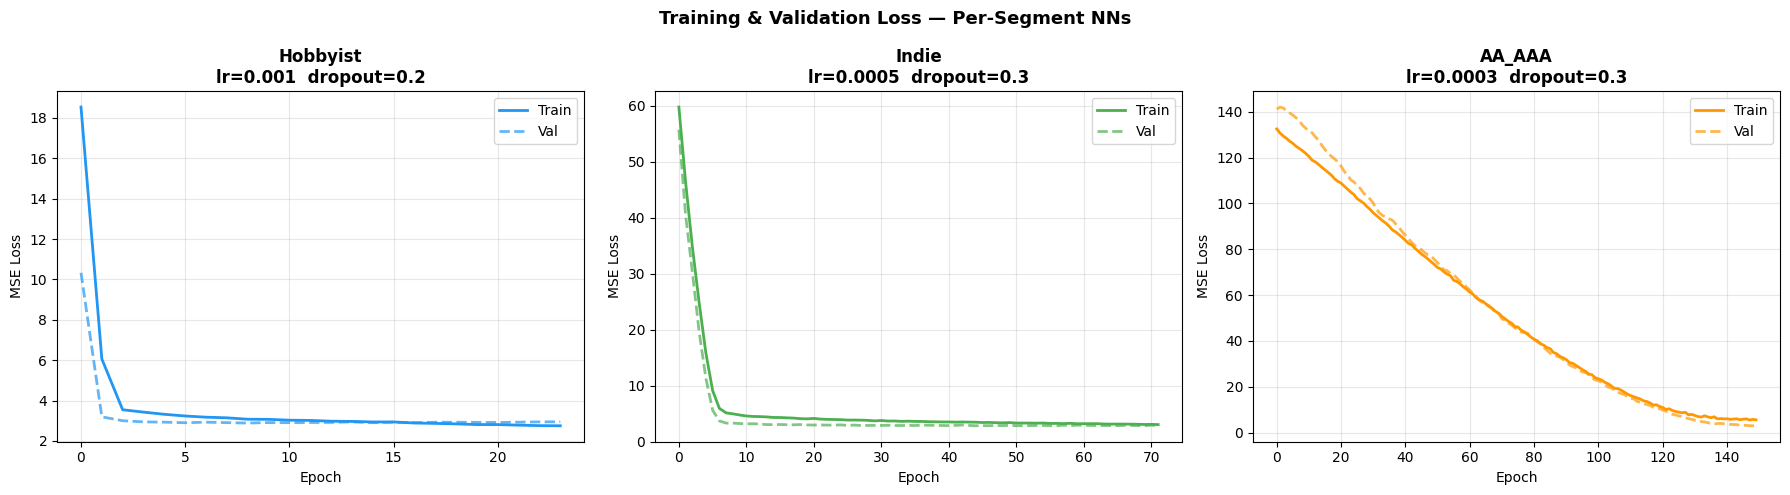

In [7]:
colors = {'Hobbyist': '#2196F3', 'Indie': '#4CAF50', 'AA_AAA': '#FF9800'}
seg_names = list(SEGMENTS.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, seg_name in zip(axes, seg_names):
    model = trained_models[seg_name]
    cfg   = SEGMENT_NN_CONFIGS[seg_name]
    ax.plot(model.history.get('train_loss', []),
            color=colors[seg_name], linewidth=2, label='Train')
    if model.history.get('val_loss'):
        ax.plot(model.history['val_loss'], color=colors[seg_name],
                linewidth=2, linestyle='--', alpha=0.7, label='Val')
    ax.set_title(f'{seg_name}\nlr={cfg["lr"]}  dropout={cfg["dropout_rate"]}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Training & Validation Loss — Per-Segment NNs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Predicted vs Actual per Segment

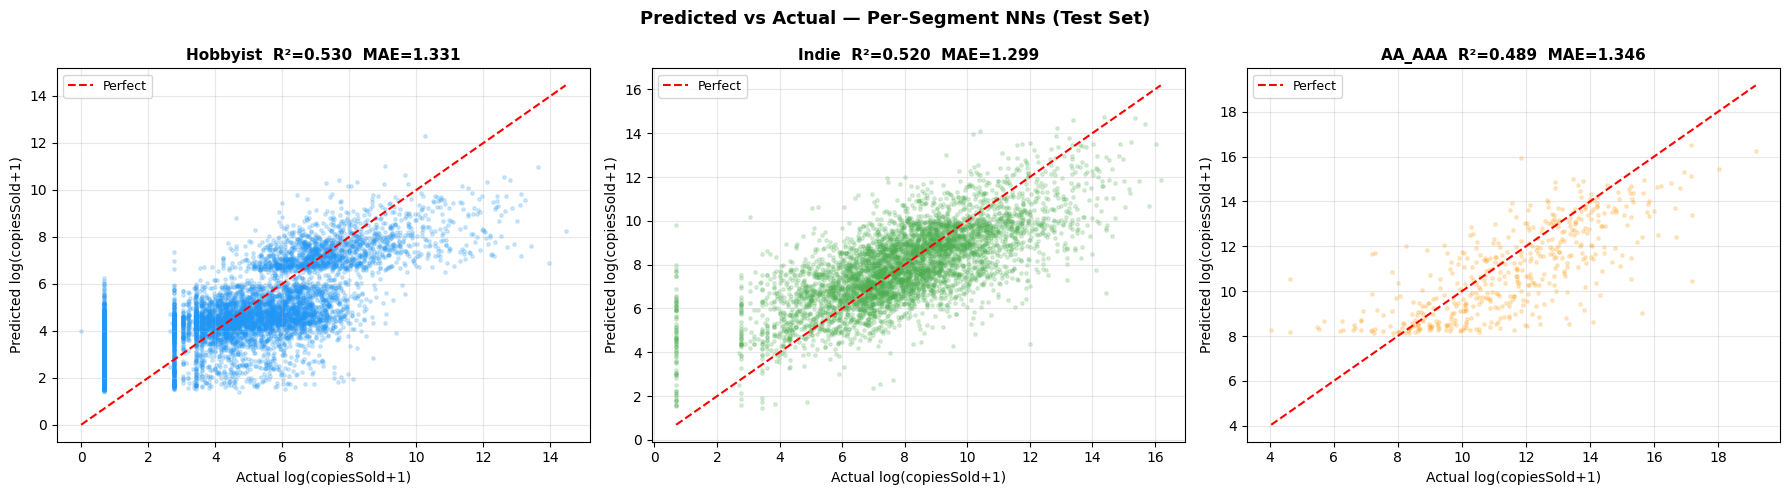

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, seg_name in zip(axes, seg_names):
    model  = trained_models[seg_name]
    splits = segment_data_splits[seg_name]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color=colors[seg_name])
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f'{seg_name}  R²={r2:.3f}  MAE={mae:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual log(copiesSold+1)')
    ax.set_ylabel('Predicted log(copiesSold+1)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Predicted vs Actual — Per-Segment NNs (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Save Test-Set Predictions & Histogram

In [ ]:
os.makedirs('cluster_outputs', exist_ok=True)

test_pred_rows = []
for seg_name, model in trained_models.items():
    splits = segment_data_splits[seg_name]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    for i in range(len(y_true)):
        test_pred_rows.append({
            'segment':          seg_name,
            'actual_log':       float(y_true[i]),
            'predicted_log':    float(y_pred[i]),
            'actual_copies':    float(np.expm1(y_true[i])),
            'predicted_copies': float(np.expm1(y_pred[i])),
            'residual_log':     float(y_pred[i] - y_true[i]),
        })

test_pred_df = pd.DataFrame(test_pred_rows)
test_pred_df.to_csv('cluster_outputs/publisher_segment_test_predictions.csv', index=False)
print(f'Saved → cluster_outputs/publisher_segment_test_predictions.csv  ({len(test_pred_df):,} rows)')
display(test_pred_df.head(6))

## 9. Random 25 Samples — Predicted vs Actual (log scale)

In [ ]:
sample25 = test_pred_df.sample(n=25, random_state=42).reset_index(drop=True)

x     = np.arange(25)
width = 0.38

seg_colors = {'Hobbyist': '#2196F3', 'Indie': '#4CAF50', 'AA_AAA': '#FF9800'}

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, sample25['actual_log'],    width, label='Actual',    color='#5C6BC0', alpha=0.85)
ax.bar(x + width/2, sample25['predicted_log'], width, label='Predicted', color='#EF5350', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f'#{i}\n({sample25.loc[i,"segment"][:3]})' for i in range(25)],
    fontsize=8,
)
for tick, seg in zip(ax.get_xticklabels(), sample25['segment']):
    tick.set_color(seg_colors[seg])

ax.set_ylabel('log1p(copiesSold)', fontsize=12)
ax.set_title('Predicted vs Actual — 25 Random Test-Set Games (log scale)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(sample25[['segment', 'actual_log', 'predicted_log', 'residual_log']]
    .rename(columns={'actual_log': 'Actual_log', 'predicted_log': 'Predicted_log', 'residual_log': 'Residual_log'})
    .style.format({'Actual_log': '{:.3f}', 'Predicted_log': '{:.3f}', 'Residual_log': '{:.3f}'})
    .background_gradient(cmap='RdYlGn_r', subset=['Residual_log'])
)

## 10. Average Test RMSE Across Segments

In [ ]:
print(f'{"Segment":<12} {"N_test":<10} {"RMSE_log":<12}')
print('-' * 38)

all_true, all_pred = [], []
for seg_name, model in trained_models.items():
    splits = segment_data_splits[seg_name]
    y_true = splits['y_test']
    y_pred = model.predict(splits['X_test'])

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f'{seg_name:<12} {len(y_true):<10,} {rmse:<12.4f}')

    all_true.append(y_true)
    all_pred.append(y_pred)

overall = float(np.sqrt(mean_squared_error(np.concatenate(all_true), np.concatenate(all_pred))))
print('-' * 38)
print(f'{"Overall":<12} {sum(len(t) for t in all_true):<10,} {overall:<12.4f}')